# K-Means Clustering

## Overview
K-Means is an **unsupervised** learning algorithm that partitions data into **K clusters** by minimizing the within-cluster sum of squared distances to the cluster centroid.

### Objective Function:
$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

Where $\mu_k$ is the centroid of cluster $k$.

### Algorithm (Lloyd's Algorithm):
1. **Initialize** K centroids randomly
2. **Assignment step**: assign each point to the nearest centroid
   $$c_i = \arg\min_k \|x_i - \mu_k\|^2$$
3. **Update step**: recompute each centroid as the mean of assigned points
   $$\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$$
4. Repeat steps 2–3 until convergence

### Key Properties:
| Property | Detail |
|----------|--------|
| Type | Unsupervised, partitional |
| Shape assumption | Spherical, equal-sized clusters |
| Distance metric | Euclidean (default) |
| K selection | Must be specified by user |
| Convergence | Guaranteed, but to local minimum |
| Complexity | O(n × K × d × iterations) |

---
### Topics Covered
1. K-Means algorithm step-by-step visualization
2. Elbow method for choosing K
3. Silhouette analysis
4. Effect of initialization (random vs K-Means++)
5. Feature scaling importance
6. K-Means limitations — non-spherical clusters
7. Real-world offline-safe dataset — customer segmentation
8. Cluster profiling and interpretation
9. K-Means for image compression
10. Evaluation metrics


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.datasets import make_blobs, make_moons, make_circles

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
}
CLUSTER_COLORS = ['#E74C3C','#2E86AB','#27AE60','#E67E22',
                  '#9B59B6','#F39C12','#1ABC9C','#E91E63']

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. K-Means Algorithm — Step-by-Step Visualization

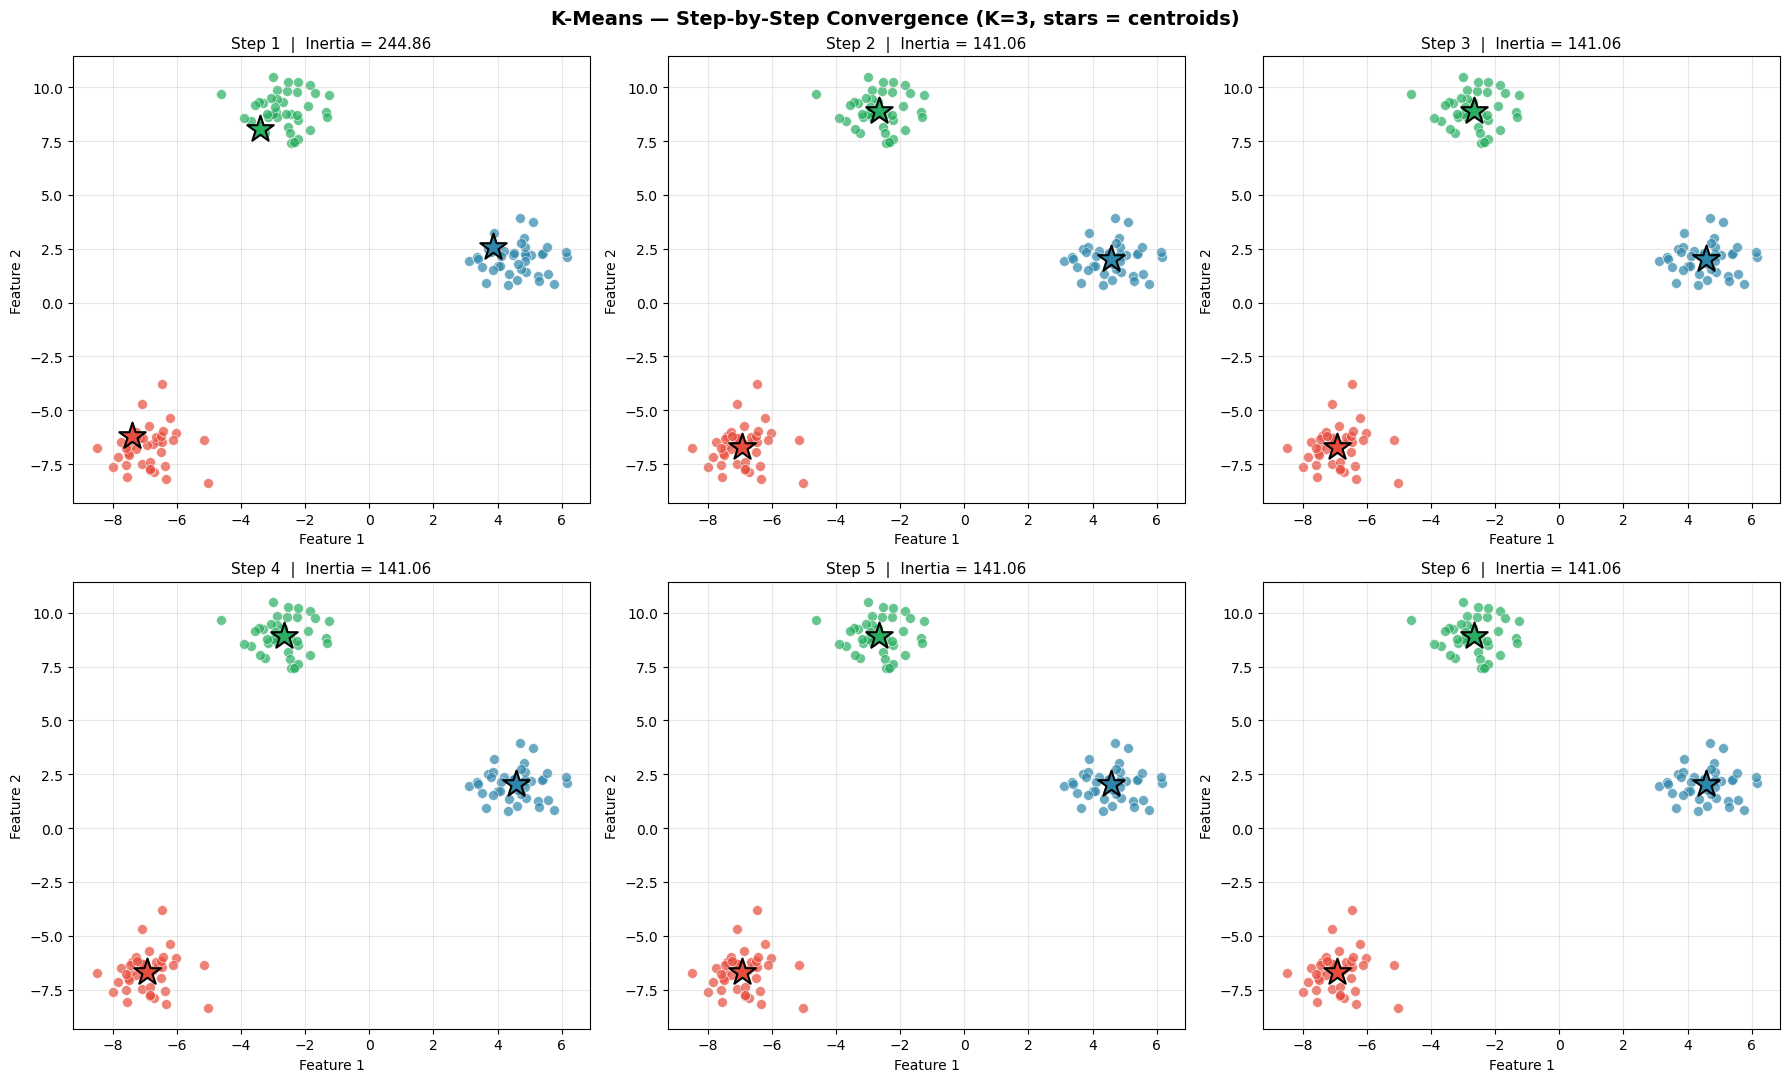

Inertia decreases monotonically with each step until convergence.
Stars show centroid positions shifting toward cluster centers.


In [2]:
np.random.seed(42)
X_demo, _ = make_blobs(n_samples=120, centers=3,
                        cluster_std=0.8, random_state=42)
K = 3

# Manual K-Means for visualization
np.random.seed(0)
centroids = X_demo[np.random.choice(len(X_demo), K, replace=False)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for step in range(6):
    ax = axes[step]

    # Assignment step
    dists   = np.linalg.norm(X_demo[:, None] - centroids[None], axis=2)
    labels  = np.argmin(dists, axis=1)

    for k in range(K):
        mask = labels == k
        ax.scatter(X_demo[mask, 0], X_demo[mask, 1],
                   color=CLUSTER_COLORS[k], s=50, alpha=0.7,
                   edgecolors='white', linewidths=0.5)
        ax.scatter(*centroids[k], color=CLUSTER_COLORS[k],
                   marker='*', s=400, edgecolors='black',
                   linewidths=1.5, zorder=5)

    inertia = sum(np.sum((X_demo[labels==k] - centroids[k])**2) for k in range(K))
    ax.set_title(f'Step {step+1}  |  Inertia = {inertia:.2f}', fontsize=11)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

    # Update step — recompute centroids
    for k in range(K):
        if np.sum(labels == k) > 0:
            centroids[k] = X_demo[labels == k].mean(axis=0)

plt.suptitle('K-Means — Step-by-Step Convergence (K=3, stars = centroids)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Inertia decreases monotonically with each step until convergence.')
print('Stars show centroid positions shifting toward cluster centers.')

## 3. Elbow Method — Choosing Optimal K

  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


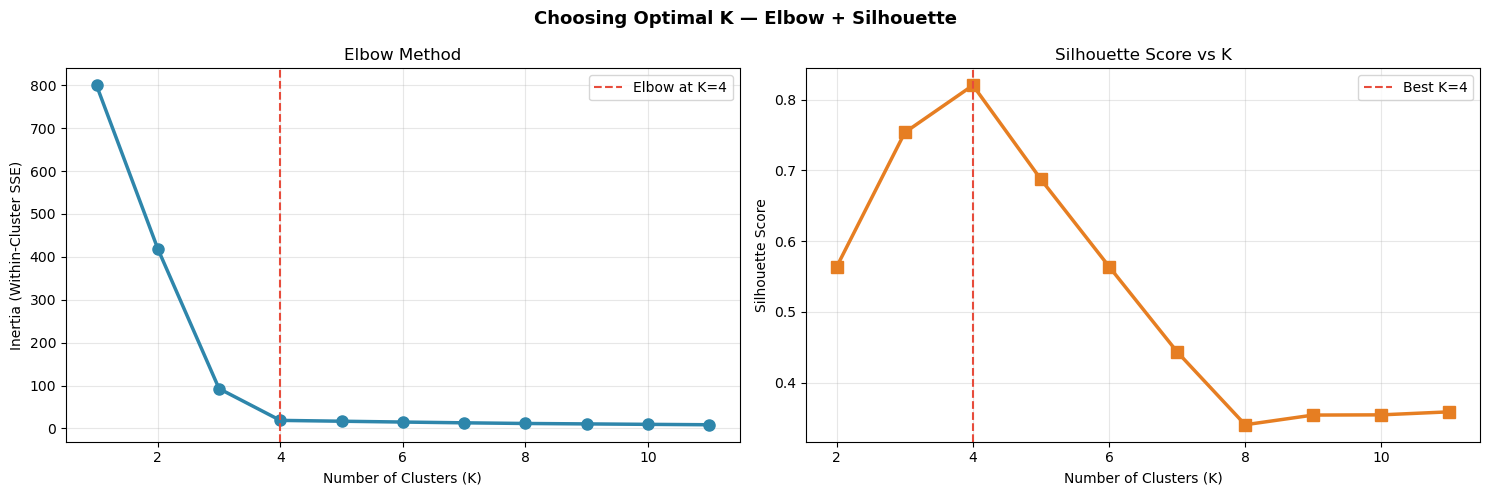

Elbow method suggests K=4 (where inertia drop slows)
Silhouette method suggests K=4 (highest score)
Use both together — agreement between methods increases confidence.


In [3]:
np.random.seed(42)
X, y_true = make_blobs(n_samples=400, centers=4,
                        cluster_std=0.9, random_state=42)

sc = StandardScaler()
X_sc = sc.fit_transform(X)

k_range   = range(1, 12)
inertias  = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_sc)
    inertias.append(km.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X_sc, km.labels_))
    else:
        sil_scores.append(np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(list(k_range), inertias, 'o-', color=COLORS['primary'],
         linewidth=2.5, markersize=8)
ax1.axvline(4, color=COLORS['danger'], linestyle='--',
            linewidth=1.5, label='Elbow at K=4')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-Cluster SSE)')
ax1.set_title('Elbow Method')
ax1.legend()

valid_k   = list(k_range)[1:]
valid_sil = sil_scores[1:]
best_k_sil = valid_k[np.argmax(valid_sil)]

ax2.plot(valid_k, valid_sil, 's-', color=COLORS['secondary'],
         linewidth=2.5, markersize=8)
ax2.axvline(best_k_sil, color=COLORS['danger'], linestyle='--',
            linewidth=1.5, label=f'Best K={best_k_sil}')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K')
ax2.legend()

plt.suptitle('Choosing Optimal K — Elbow + Silhouette',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Elbow method suggests K=4 (where inertia drop slows)')
print(f'Silhouette method suggests K={best_k_sil} (highest score)')
print('Use both together — agreement between methods increases confidence.')

## 4. Silhouette Analysis — Per-Sample & Per-Cluster

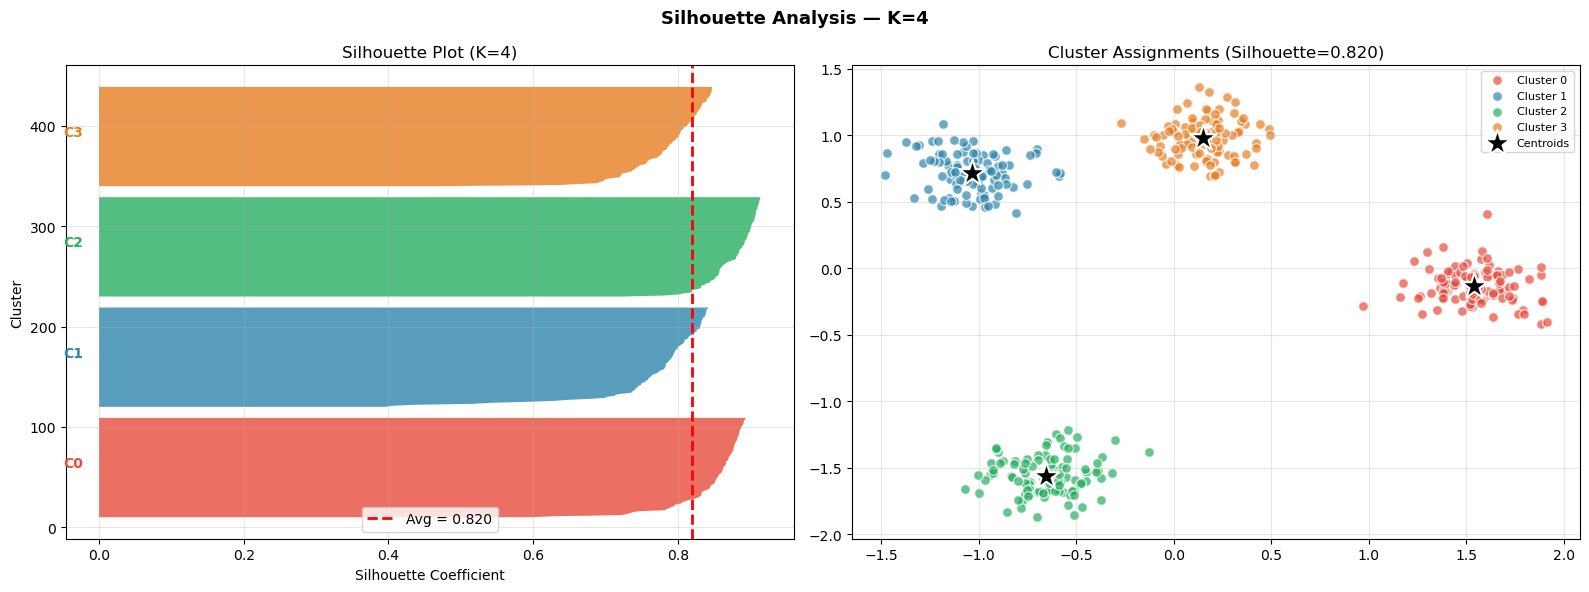

Average Silhouette Score : 0.8202
Score interpretation:
  0.71 - 1.00  -> Strong structure
  0.51 - 0.70  -> Reasonable structure
  0.26 - 0.50  -> Weak structure
  < 0.25       -> No substantial structure


In [4]:
km_best = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels  = km_best.fit_predict(X_sc)

sil_vals    = silhouette_samples(X_sc, labels)
sil_avg     = silhouette_score(X_sc, labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Silhouette plot
y_lower = 10
for k in range(4):
    k_sil = np.sort(sil_vals[labels == k])
    size_k = len(k_sil)
    y_upper = y_lower + size_k
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, k_sil,
                      facecolor=CLUSTER_COLORS[k], alpha=0.8)
    ax1.text(-0.05, y_lower + size_k/2, f'C{k}', fontsize=10,
             color=CLUSTER_COLORS[k], fontweight='bold')
    y_lower = y_upper + 10

ax1.axvline(sil_avg, color='red', linestyle='--',
            linewidth=2, label=f'Avg = {sil_avg:.3f}')
ax1.set_xlabel('Silhouette Coefficient')
ax1.set_ylabel('Cluster')
ax1.set_title('Silhouette Plot (K=4)')
ax1.legend()

# Cluster scatter
for k in range(4):
    mask = labels == k
    ax2.scatter(X_sc[mask, 0], X_sc[mask, 1],
                color=CLUSTER_COLORS[k], s=50, alpha=0.7,
                edgecolors='white', label=f'Cluster {k}')
centers = km_best.cluster_centers_
ax2.scatter(centers[:, 0], centers[:, 1],
            marker='*', s=400, color='black',
            edgecolors='white', linewidths=1.5,
            zorder=5, label='Centroids')
ax2.set_title(f'Cluster Assignments (Silhouette={sil_avg:.3f})')
ax2.legend(fontsize=8)

plt.suptitle('Silhouette Analysis — K=4', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Average Silhouette Score : {sil_avg:.4f}')
print('Score interpretation:')
print('  0.71 - 1.00  -> Strong structure')
print('  0.51 - 0.70  -> Reasonable structure')
print('  0.26 - 0.50  -> Weak structure')
print('  < 0.25       -> No substantial structure')

## 5. Initialization — Random vs K-Means++

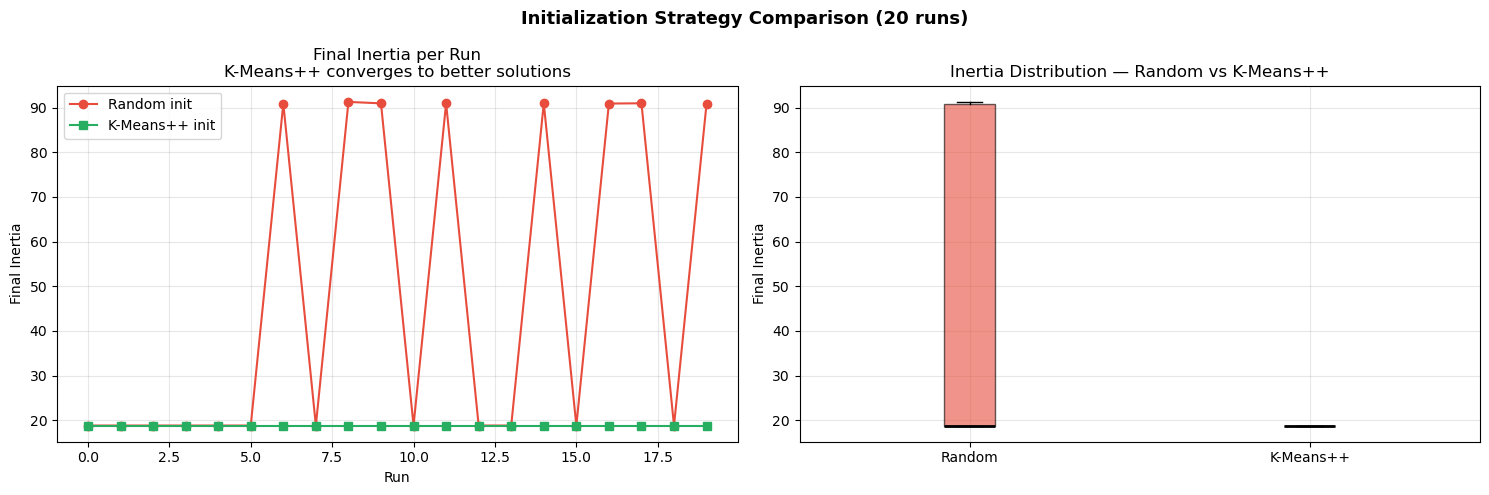

Random init    -> Mean inertia: 47.69  Std: 35.34
K-Means++ init -> Mean inertia: 18.84  Std: 0.00
K-Means++ avg iterations: 2.0 vs Random: 5.3

K-Means++ spreads initial centroids far apart -> better starting point
-> Lower final inertia, fewer iterations, more consistent results


In [5]:
n_runs    = 20
random_inertias  = []
kpp_inertias     = []
random_iters     = []
kpp_iters        = []

for seed in range(n_runs):
    km_rand = KMeans(n_clusters=4, init='random',    n_init=1, random_state=seed, max_iter=300)
    km_kpp  = KMeans(n_clusters=4, init='k-means++', n_init=1, random_state=seed, max_iter=300)
    km_rand.fit(X_sc)
    km_kpp.fit(X_sc)
    random_inertias.append(km_rand.inertia_)
    kpp_inertias.append(km_kpp.inertia_)
    random_iters.append(km_rand.n_iter_)
    kpp_iters.append(km_kpp.n_iter_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(random_inertias, 'o-', color=COLORS['danger'],
             linewidth=1.5, markersize=6, label='Random init')
axes[0].plot(kpp_inertias,    's-', color=COLORS['success'],
             linewidth=1.5, markersize=6, label='K-Means++ init')
axes[0].set_xlabel('Run'); axes[0].set_ylabel('Final Inertia')
axes[0].set_title('Final Inertia per Run\nK-Means++ converges to better solutions')
axes[0].legend()

bp = axes[1].boxplot([random_inertias, kpp_inertias],
                     labels=['Random', 'K-Means++'],
                     patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(COLORS['danger'])
bp['boxes'][1].set_facecolor(COLORS['success'])
for box in bp['boxes']:
    box.set_alpha(0.6)
axes[1].set_ylabel('Final Inertia')
axes[1].set_title('Inertia Distribution — Random vs K-Means++')

plt.suptitle('Initialization Strategy Comparison (20 runs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Random init    -> Mean inertia: {np.mean(random_inertias):.2f}  Std: {np.std(random_inertias):.2f}')
print(f'K-Means++ init -> Mean inertia: {np.mean(kpp_inertias):.2f}  Std: {np.std(kpp_inertias):.2f}')
print(f'K-Means++ avg iterations: {np.mean(kpp_iters):.1f} vs Random: {np.mean(random_iters):.1f}')
print()
print('K-Means++ spreads initial centroids far apart -> better starting point')
print('-> Lower final inertia, fewer iterations, more consistent results')

## 6. Feature Scaling Importance

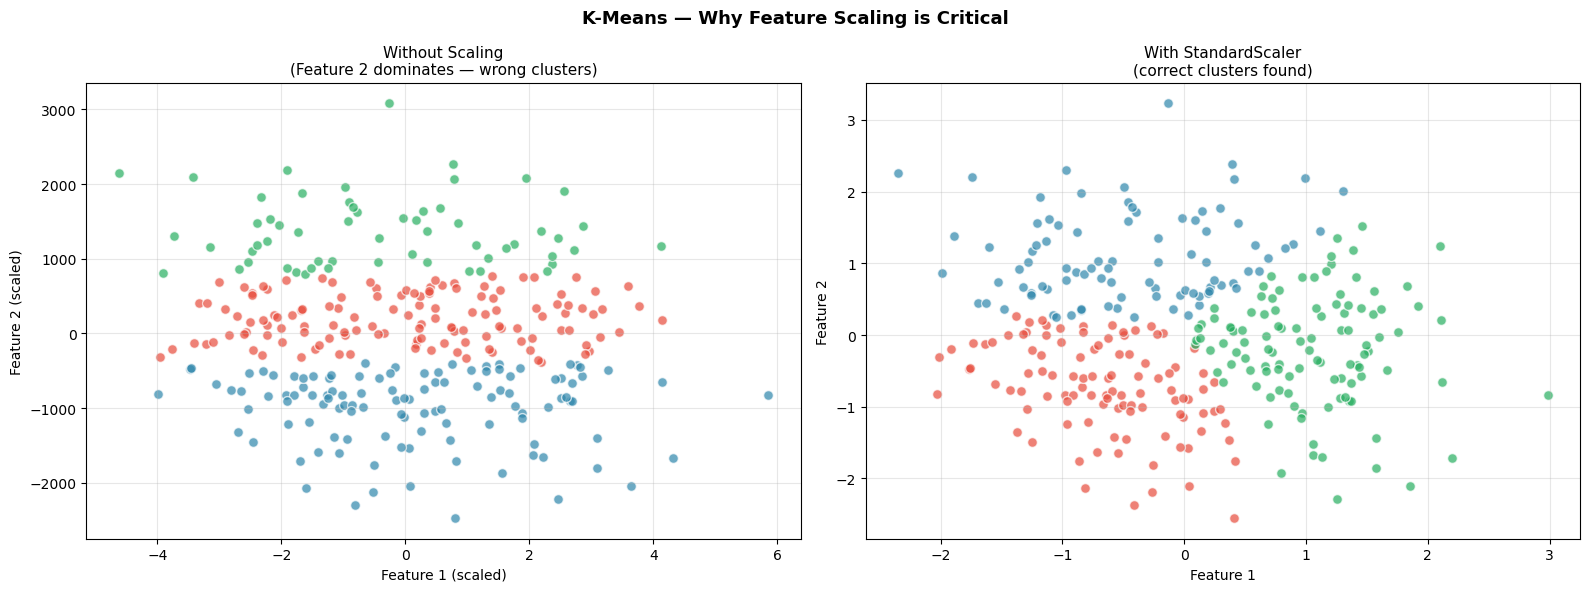

Without scaling: large-scale Feature 2 (std=1000) dominates Euclidean distance.
With scaling   : both features contribute equally -> correct structure found.
ALWAYS scale features before applying K-Means!


In [6]:
np.random.seed(42)
# Create data where one feature dominates due to scale
n = 300
X_unscaled = np.column_stack([
    np.random.randn(n) * 1,      # small scale: std=1
    np.random.randn(n) * 1000    # large scale: std=1000
])
# True clusters based on Feature 1 (small scale)
X_unscaled[:100,  0] -= 2
X_unscaled[100:200, 0] += 0
X_unscaled[200:,  0] += 2

X_unscaled_sc = StandardScaler().fit_transform(X_unscaled)

km_unsc = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km_sc   = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels_unsc = km_unsc.fit_predict(X_unscaled)
labels_sc   = km_sc.fit_predict(X_unscaled_sc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, X_plot, title in zip(
    axes,
    [labels_unsc, labels_sc],
    [X_unscaled, X_unscaled_sc],
    ['Without Scaling\n(Feature 2 dominates — wrong clusters)',
     'With StandardScaler\n(correct clusters found)']
):
    for k in range(3):
        mask = labels == k
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   color=CLUSTER_COLORS[k], s=50, alpha=0.7,
                   edgecolors='white')
    ax.set_xlabel('Feature 1 (scaled)' if 'Scaling' in title else 'Feature 1')
    ax.set_ylabel('Feature 2 (scaled)' if 'Scaling' in title else 'Feature 2')
    ax.set_title(title, fontsize=11)

plt.suptitle('K-Means — Why Feature Scaling is Critical',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Without scaling: large-scale Feature 2 (std=1000) dominates Euclidean distance.')
print('With scaling   : both features contribute equally -> correct structure found.')
print('ALWAYS scale features before applying K-Means!')

## 7. K-Means Limitations — Non-Spherical Clusters

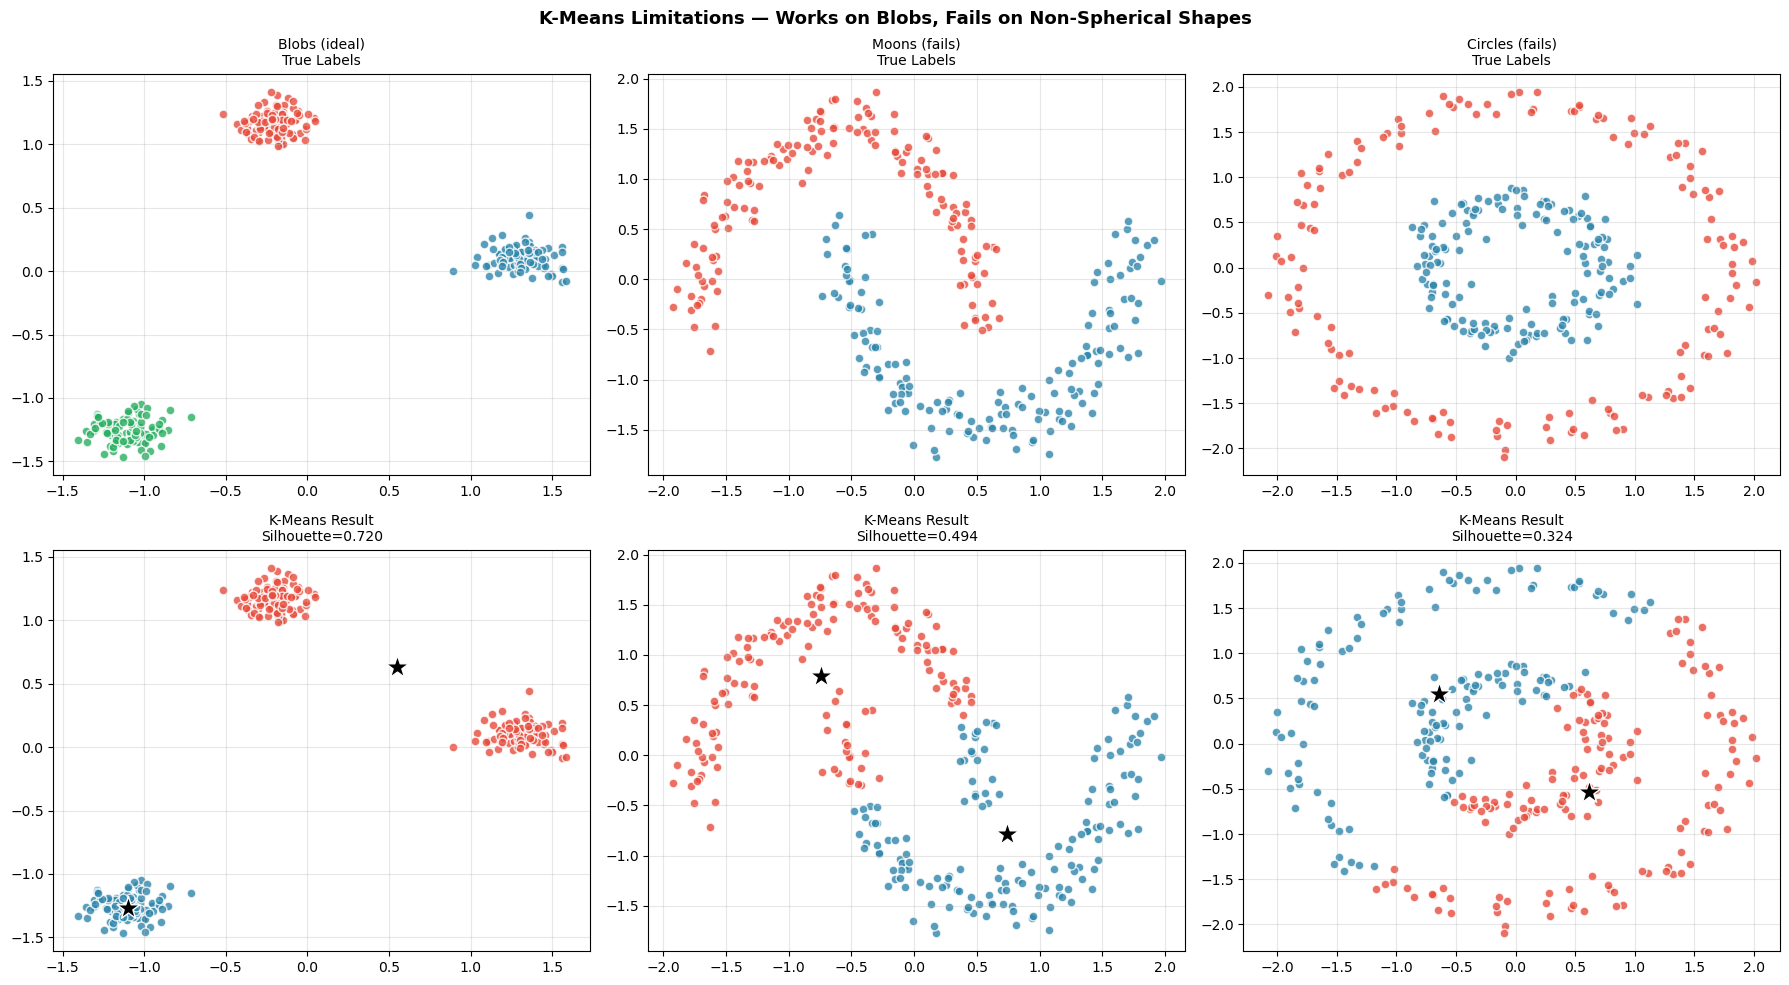

K-Means assumes: convex, spherical, equal-sized clusters.
For non-spherical data -> use DBSCAN or Spectral Clustering instead.


In [7]:
np.random.seed(42)
datasets = {
    'Blobs (ideal)':  make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42),
    'Moons (fails)':  make_moons(n_samples=300, noise=0.08, random_state=42),
    'Circles (fails)':make_circles(n_samples=300, noise=0.06, factor=0.4, random_state=42),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (name, (X_ds, y_ds)) in enumerate(datasets.items()):
    X_ds_sc = StandardScaler().fit_transform(X_ds)
    km_ds   = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
    pred    = km_ds.fit_predict(X_ds_sc)
    sil     = silhouette_score(X_ds_sc, pred)

    # True labels
    ax_true = axes[0][col]
    for k in np.unique(y_ds):
        ax_true.scatter(X_ds_sc[y_ds==k, 0], X_ds_sc[y_ds==k, 1],
                        color=CLUSTER_COLORS[k], s=40, alpha=0.8, edgecolors='white')
    ax_true.set_title(f'{name}\nTrue Labels', fontsize=10)

    # K-Means labels
    ax_km = axes[1][col]
    for k in range(2):
        ax_km.scatter(X_ds_sc[pred==k, 0], X_ds_sc[pred==k, 1],
                      color=CLUSTER_COLORS[k], s=40, alpha=0.8, edgecolors='white')
    centers = km_ds.cluster_centers_
    ax_km.scatter(centers[:,0], centers[:,1], marker='*', s=300,
                  color='black', edgecolors='white', zorder=5)
    ax_km.set_title(f'K-Means Result\nSilhouette={sil:.3f}', fontsize=10)

plt.suptitle('K-Means Limitations — Works on Blobs, Fails on Non-Spherical Shapes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('K-Means assumes: convex, spherical, equal-sized clusters.')
print('For non-spherical data -> use DBSCAN or Spectral Clustering instead.')

## 8. Real-World Offline-Safe Dataset — Customer Segmentation

Customer dataset shape : (500, 7)
Features               : ['Age', 'AnnualIncome', 'SpendingScore', 'PurchaseFreq', 'AvgOrderValue', 'DaysSinceLast', 'LoyaltyYears']


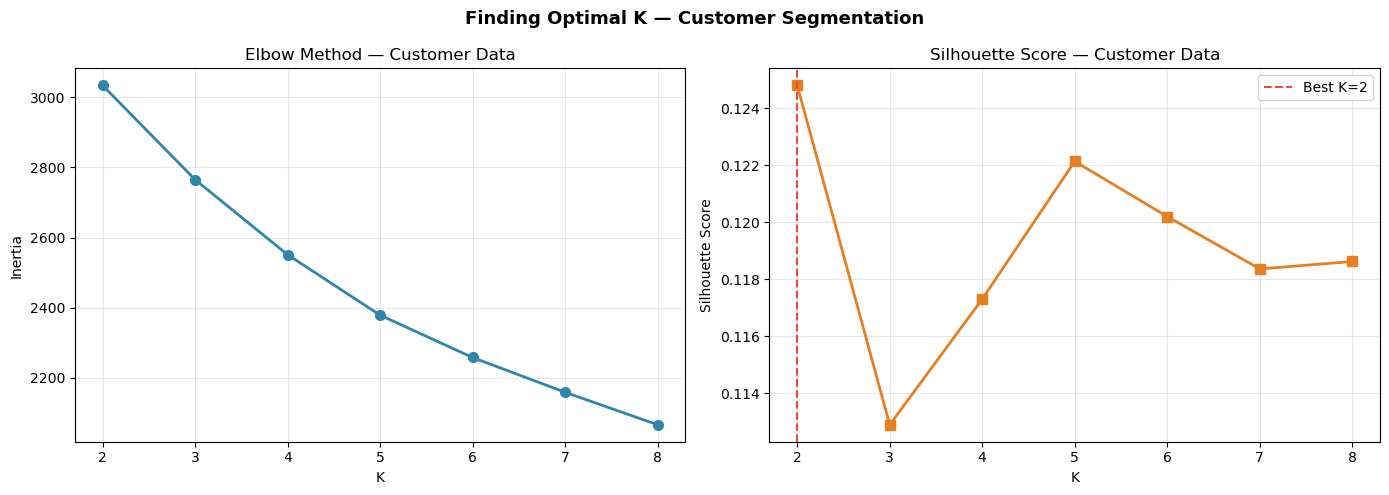

Optimal K by silhouette: 2


In [8]:
np.random.seed(42)
n_cust = 500

# Simulate RFM-style customer data
Age             = np.random.randint(18, 75, n_cust).astype(float)
AnnualIncome    = np.random.uniform(15000, 200000, n_cust)
SpendingScore   = np.random.uniform(1, 100, n_cust)
PurchaseFreq    = np.random.randint(1, 52, n_cust).astype(float)
AvgOrderValue   = np.random.uniform(20, 500, n_cust)
DaysSinceLast   = np.random.randint(1, 365, n_cust).astype(float)
LoyaltyYears    = np.random.uniform(0, 15, n_cust)

# Inject realistic cluster structure
# High-value: high income, high spending, frequent
idx_hv = np.random.choice(n_cust, 100, replace=False)
AnnualIncome[idx_hv] += 60000
SpendingScore[idx_hv] += 30
PurchaseFreq[idx_hv]  += 20

# Budget: low income, low spending
idx_bud = np.random.choice(
    np.setdiff1d(range(n_cust), idx_hv), 120, replace=False
)
AnnualIncome[idx_bud]  -= 5000
SpendingScore[idx_bud] -= 20

feat_names_cust = ['Age','AnnualIncome','SpendingScore',
                   'PurchaseFreq','AvgOrderValue','DaysSinceLast','LoyaltyYears']
X_cust = np.column_stack([Age, AnnualIncome, SpendingScore,
                           PurchaseFreq, AvgOrderValue,
                           DaysSinceLast, LoyaltyYears])
X_cust = np.clip(X_cust, 0, None)   # no negatives

print(f'Customer dataset shape : {X_cust.shape}')
print(f'Features               : {feat_names_cust}')

# Scale features
sc_cust   = StandardScaler()
X_cust_sc = sc_cust.fit_transform(X_cust)

# Find optimal K
k_range_c  = range(2, 9)
inertias_c = []
sil_c      = []
for k in k_range_c:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_cust_sc)
    inertias_c.append(km.inertia_)
    sil_c.append(silhouette_score(X_cust_sc, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(k_range_c), inertias_c, 'o-', color=COLORS['primary'], linewidth=2, markersize=7)
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method — Customer Data')

best_k_c = list(k_range_c)[np.argmax(sil_c)]
ax2.plot(list(k_range_c), sil_c, 's-', color=COLORS['secondary'], linewidth=2, markersize=7)
ax2.axvline(best_k_c, color=COLORS['danger'], linestyle='--', linewidth=1.5,
            label=f'Best K={best_k_c}')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score — Customer Data')
ax2.legend()

plt.suptitle('Finding Optimal K — Customer Segmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Optimal K by silhouette: {best_k_c}')

## 9. Cluster Profiling — Understanding Each Segment

=== Cluster Profiles (feature means) ===
          Age  AnnualIncome  SpendingScore  PurchaseFreq  AvgOrderValue  DaysSinceLast  LoyaltyYears
Cluster                                                                                             
0        46.0      161238.8           69.1          40.2          222.7          199.7           6.9
1        46.4       84337.6           39.0          22.8          273.6          181.2           8.2

Cluster sizes:
Cluster
0    215
1    285
Name: count, dtype: int64


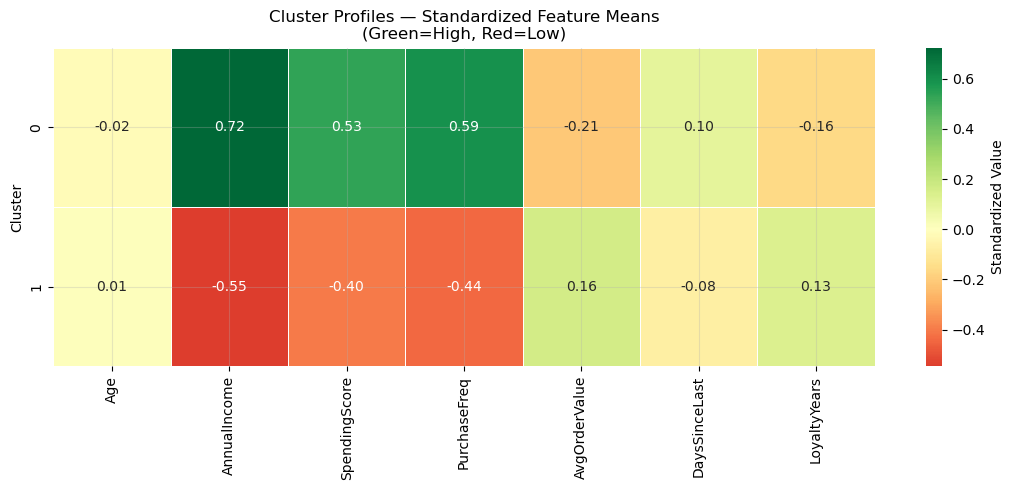

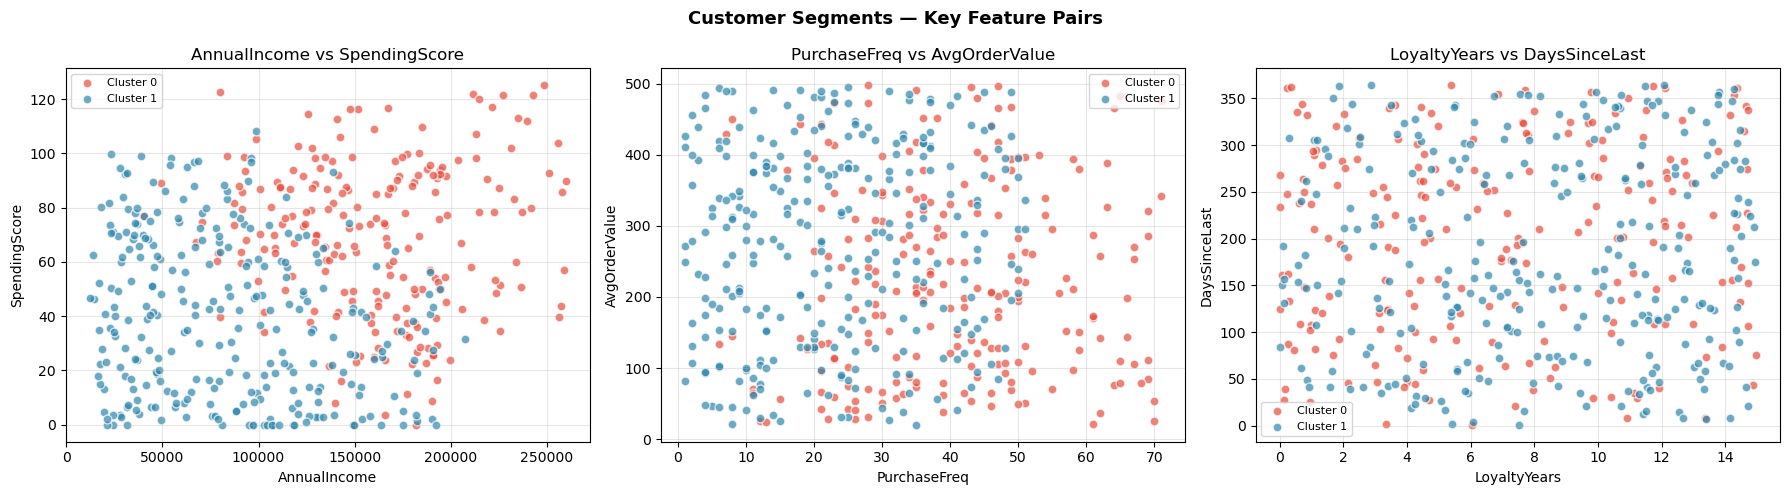

In [9]:
km_cust = KMeans(n_clusters=best_k_c, init='k-means++',
                 n_init=10, random_state=42)
cust_labels = km_cust.fit_predict(X_cust_sc)

df_cust = pd.DataFrame(X_cust, columns=feat_names_cust)
df_cust['Cluster'] = cust_labels

# Cluster profiles
profile = df_cust.groupby('Cluster')[feat_names_cust].mean().round(1)
print('=== Cluster Profiles (feature means) ===')
print(profile.to_string())
print()
print('Cluster sizes:')
print(df_cust['Cluster'].value_counts().sort_index())

# Heatmap of cluster profiles (standardized)
profile_sc = pd.DataFrame(
    sc_cust.transform(profile.values),
    index=profile.index,
    columns=feat_names_cust
)

plt.figure(figsize=(11, 5))
sns.heatmap(profile_sc, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5,
            cbar_kws={'label': 'Standardized Value'})
plt.title('Cluster Profiles — Standardized Feature Means\n(Green=High, Red=Low)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

# Pairplot for 3 key features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [('AnnualIncome','SpendingScore'),
         ('PurchaseFreq','AvgOrderValue'),
         ('LoyaltyYears','DaysSinceLast')]

for ax, (fx, fy) in zip(axes, pairs):
    for k in range(best_k_c):
        mask = cust_labels == k
        ax.scatter(df_cust.loc[mask, fx], df_cust.loc[mask, fy],
                   color=CLUSTER_COLORS[k], s=40, alpha=0.7,
                   edgecolors='white', label=f'Cluster {k}')
    ax.set_xlabel(fx); ax.set_ylabel(fy)
    ax.set_title(f'{fx} vs {fy}')
    ax.legend(fontsize=8)

plt.suptitle('Customer Segments — Key Feature Pairs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. K-Means for Image Compression

In [ ]:
# Create a synthetic colorful image (no file I/O needed)
np.random.seed(42)
H, W = 80, 80

img = np.zeros((H, W, 3), dtype=np.float32)
# Quadrants with different colors + noise
img[:40, :40]  = [0.9, 0.2, 0.2]   # red
img[:40, 40:]  = [0.2, 0.6, 0.9]   # blue
img[40:, :40]  = [0.2, 0.8, 0.3]   # green
img[40:, 40:]  = [0.9, 0.7, 0.1]   # yellow
img += np.random.randn(H, W, 3) * 0.12
img  = np.clip(img, 0, 1)

pixels    = img.reshape(-1, 3)
n_colors_list = [2, 4, 8, 16]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(img)
axes[0].set_title('Original\n(infinite colors)')
axes[0].axis('off')

for ax, n_colors in zip(axes[1:], n_colors_list):
    km_img = KMeans(n_clusters=n_colors, init='k-means++',
                    n_init=3, random_state=42)
    km_img.fit(pixels)
    compressed = km_img.cluster_centers_[km_img.labels_].reshape(H, W, 3)
    compressed = np.clip(compressed, 0, 1)

    ax.imshow(compressed)
    ax.set_title(f'{n_colors} colors\n(K={n_colors})')
    ax.axis('off')

plt.suptitle('K-Means Image Compression — Reducing Color Palette',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

orig_bits = H * W * 3 * 8
for n_colors in n_colors_list:
    bits = H * W * np.log2(n_colors) + n_colors * 3 * 8
    ratio = orig_bits / bits
    print(f'K={n_colors:3d} colors -> compression ratio ~ {ratio:.1f}x')

## 11. Evaluation Metrics Summary

In [ ]:
k_range_e = range(2, 9)
metrics   = {'K': [], 'Inertia': [], 'Silhouette': [],
             'Davies-Bouldin': [], 'Calinski-Harabasz': []}

for k in k_range_e:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl = km.fit_predict(X_sc)
    metrics['K'].append(k)
    metrics['Inertia'].append(km.inertia_)
    metrics['Silhouette'].append(silhouette_score(X_sc, lbl))
    metrics['Davies-Bouldin'].append(davies_bouldin_score(X_sc, lbl))
    metrics['Calinski-Harabasz'].append(calinski_harabasz_score(X_sc, lbl))

met_df = pd.DataFrame(metrics)
print('=== Clustering Evaluation Metrics ===')
print(met_df.round(3).to_string(index=False))
print()
print('Metric guide:')
print('  Inertia            -> lower is better (but always decreases with K)')
print('  Silhouette         -> higher is better (range -1 to 1)')
print('  Davies-Bouldin     -> lower is better (0 = perfect)')
print('  Calinski-Harabasz  -> higher is better')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
metric_cols   = ['Inertia','Silhouette','Davies-Bouldin','Calinski-Harabasz']
metric_colors = [COLORS['primary'], COLORS['success'],
                 COLORS['danger'],  COLORS['secondary']]

for ax, col, color in zip(axes, metric_cols, metric_colors):
    ax.plot(met_df['K'], met_df[col], 'o-', color=color,
            linewidth=2.5, markersize=8)
    ax.set_xlabel('K'); ax.set_ylabel(col)
    ax.set_title(col)

plt.suptitle('All Clustering Metrics vs K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Final Summary & Key Takeaways

In [ ]:
print('=' * 66)
print('              K-MEANS CLUSTERING - KEY TAKEAWAYS')
print('=' * 66)

takeaways = [
    ('Algorithm',        'Iterative: assign to nearest centroid, update centroid mean'),
    ('Objective',        'Minimize within-cluster sum of squared distances (inertia)'),
    ('K selection',      'Elbow method + Silhouette score + domain knowledge'),
    ('Init K-Means++',   'Spreads centroids -> better start, fewer iterations'),
    ('n_init',           'Run multiple times with different inits, keep best result'),
    ('Feature scaling',  'ALWAYS scale — K-Means uses Euclidean distance'),
    ('Silhouette',       '> 0.5 = reasonable, > 0.7 = strong cluster structure'),
    ('Davies-Bouldin',   'Lower = better separated clusters'),
    ('Limitations',      'Assumes spherical, equal-size clusters; sensitive to outliers'),
    ('Local minima',     'Converges to local not global minimum -> use n_init > 1'),
    ('Use cases',        'Customer segmentation, image compression, anomaly detection'),
    ('Alternatives',     'DBSCAN (arbitrary shapes), GMM (soft clusters), Agglomerative'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<20}  ->  {detail}')

print('=' * 66)

---
## Practice Exercises

1. **Vary n_init** from 1 to 20 and plot how inertia stability changes — at what point does it plateau?
2. **Add outliers** to the blob dataset and observe how centroids are pulled toward them.
3. **Compare K-Means vs DBSCAN** on the moons and circles datasets.
4. **Apply to PCA-reduced data** — run PCA(n_components=2) first, then cluster and visualize.
5. **Build a customer persona** for each cluster using the profiling heatmap.
6. **Implement K-Means from scratch** using only NumPy and verify it matches sklearn's output.

---
*Notebook created for the ML Repository — K-Means Clustering module.*